Добейтесь на автокодировщике с 2-мерным скрытым пространством на 3-х цифрах: 0, 1 и 3 – ошибки MSE**<0.034** на скорости обучения **0.001** на **10-й эпохе**.

In [1]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.layers import (
    Input,
    Dense,
    Flatten,
    Reshape,
    Conv2D,
    MaxPooling2D,
    Conv2DTranspose,
    BatchNormalization,
)

%matplotlib inline


In [2]:
def remove_saved_plots(mask='*.jpg'):
    # Перед новым запуском удаляем старые изображения
    for file_name in glob.glob(mask):
        os.remove(file_name)


def show_latent_space(epoch, logs):
    # Функция вызывается после каждой эпохи обучения
    current_loss = logs.get('loss')
    print(f'ЭПОХА: {epoch + 1}, loss: {current_loss}')

    # Энкодер переводит изображения цифр в двумерное скрытое пространство
    encoded_points = encoder.predict(X_train, verbose=0)

    plt.figure(dpi=100)
    scatter = plt.scatter(
        encoded_points[:, 0],
        encoded_points[:, 1],
        c=y_train,
        alpha=0.6,
        s=5
    )

    plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')
    plt.title(f'Скрытое пространство после эпохи {epoch + 1}')
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')

    # Сохраняем график
    plot_id = len(glob.glob('*.jpg'))
    plt.savefig(f'image_{plot_id}.jpg')
    plt.show()


ae_callback = LambdaCallback(on_epoch_end=show_latent_space)

# Очищаем старые картинки перед обучением
remove_saved_plots()


In [3]:
def load_mnist_digits(required_digits):
    # Загружаем MNIST и оставляем только нужные цифры
    (images_train, labels_train), _ = mnist.load_data()

    images_train = images_train.astype('float32') / 255.0

    images_train = images_train.reshape(-1, 28, 28, 1)

    digit_mask = np.isin(labels_train, required_digits)

    return images_train[digit_mask], labels_train[digit_mask]

target_digits = [0, 1, 3]
X_train, y_train = load_mnist_digits(target_digits)

print(f'Размер отфильтрованной обучающей выборки: {X_train.shape}')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размер отфильтрованной обучающей выборки: (18796, 28, 28, 1)


In [4]:
def build_encoder(input_shape=(28, 28, 1)):
    # Энкодер сжимает изображение цифры в две координаты
    image_input = Input(shape=input_shape, name='encoder_input')

    layer = Conv2D(32, (3, 3), padding='same', activation='relu')(image_input)
    layer = BatchNormalization()(layer)
    layer = MaxPooling2D((2, 2))(layer)

    layer = Conv2D(64, (3, 3), padding='same', activation='relu')(layer)
    layer = BatchNormalization()(layer)
    layer = MaxPooling2D((2, 2))(layer)

    layer = Flatten()(layer)
    layer = Dense(64, activation='relu')(layer)

    code = Dense(2, activation='linear', name='latent_2d')(layer)

    return Model(image_input, code, name='encoder')


def build_decoder(latent_size=2):
    # Декодер восстанавливает изображение из двух координат скрытого пространства
    code_input = Input(shape=(latent_size,), name='decoder_input')

    layer = Dense(7 * 7 * 64, activation='relu')(code_input)
    layer = Reshape((7, 7, 64))(layer)

    layer = Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(layer)
    layer = BatchNormalization()(layer)

    layer = Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(layer)
    layer = BatchNormalization()(layer)

    restored_image = Conv2D(1, (3, 3), padding='same', activation='sigmoid', name='decoder_output')(layer)

    return Model(code_input, restored_image, name='decoder')


def build_autoencoder(learning_rate=0.001):
    input_image = Input(shape=(28, 28, 1), name='autoencoder_input')

    hidden_code = encoder(input_image)
    reconstructed_image = decoder(hidden_code)

    model = Model(input_image, reconstructed_image, name='conv_autoencoder')

    # MSE и скорость обучения 0.001
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse'
    )

    return model


encoder = build_encoder()
decoder = build_decoder()
autoencoder = build_autoencoder(learning_rate=0.001)

autoencoder.summary()


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │       220,098 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        65,473 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,571 (1.09 MB)

 Trainable params: 285,187 (1.09 MB)

 Non-trainable params: 384 (1.50 KB)

Старт обучения свёрточного автокодировщика...
Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1197________________________
ЭПОХА: 1, loss: 0.07580186426639557
________________________


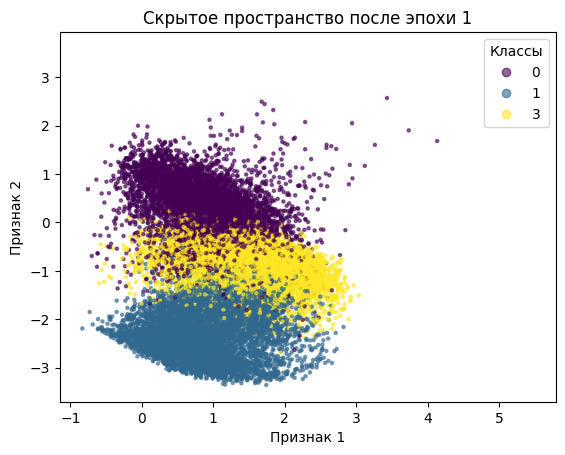

147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - loss: 0.0758
Epoch 2/10
145/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0398________________________
ЭПОХА: 2, loss: 0.0377020500600338
________________________


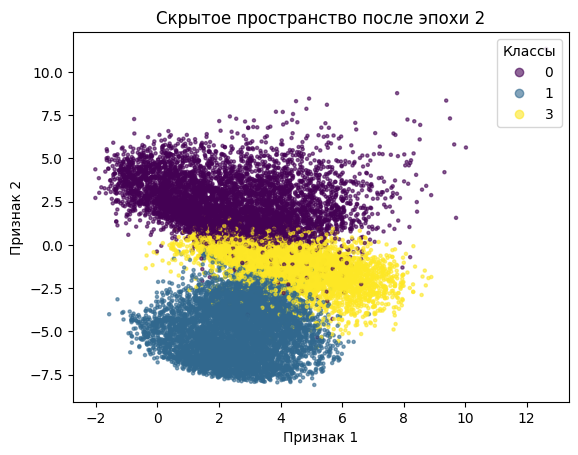

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0377
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0328________________________
ЭПОХА: 3, loss: 0.0321090891957283
________________________


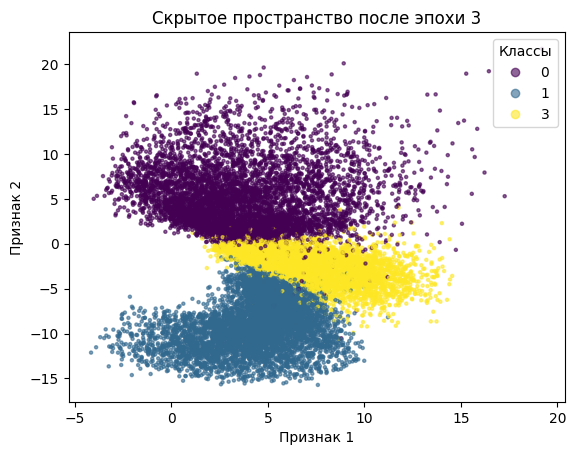

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0321
Epoch 4/10
143/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0308________________________
ЭПОХА: 4, loss: 0.03060719557106495
________________________


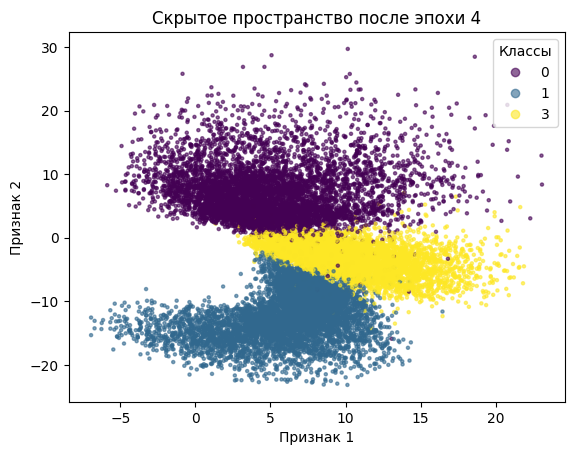

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0306
Epoch 5/10
143/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0301________________________
ЭПОХА: 5, loss: 0.029935307800769806
________________________


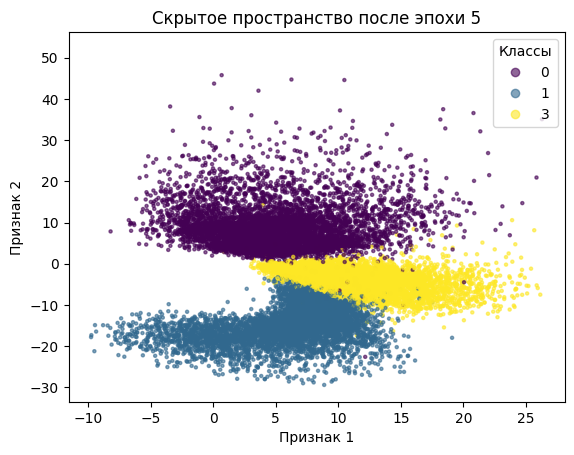

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0299
Epoch 6/10
142/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0295________________________
ЭПОХА: 6, loss: 0.029450206086039543
________________________


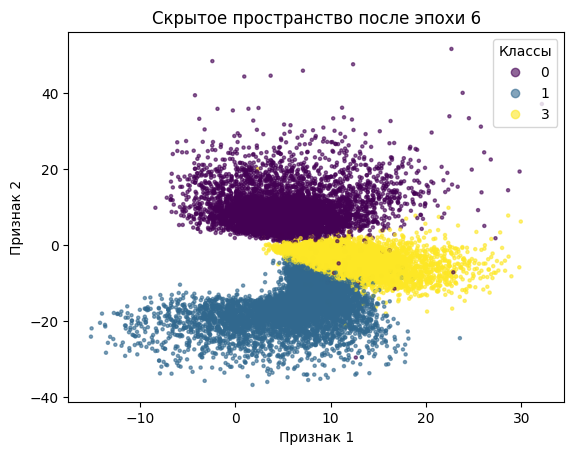

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0295
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0292________________________
ЭПОХА: 7, loss: 0.029154391959309578
________________________


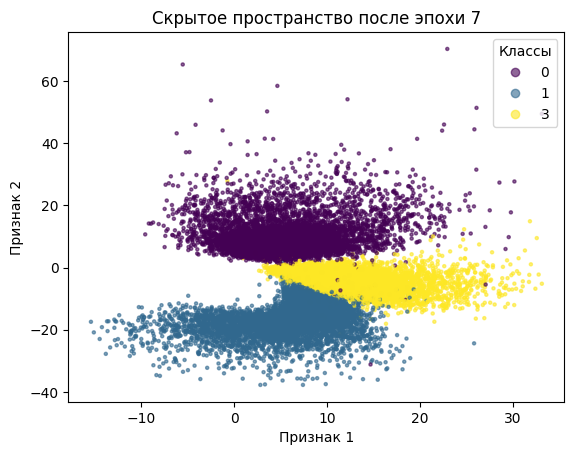

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0292
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0291________________________
ЭПОХА: 8, loss: 0.02894843928515911
________________________


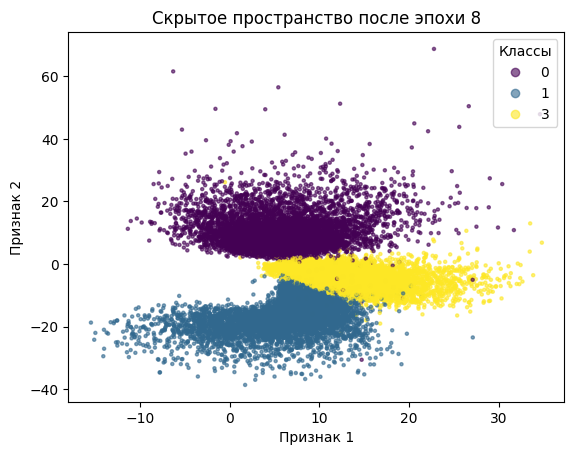

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0289
Epoch 9/10
142/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0287________________________
ЭПОХА: 9, loss: 0.028726577758789062
________________________


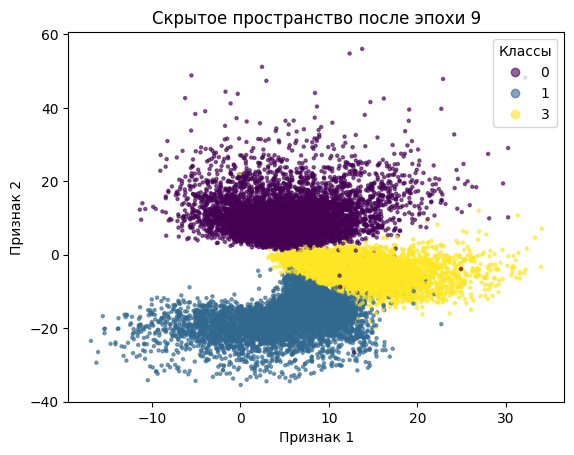

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0287
Epoch 10/10
145/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0286________________________
ЭПОХА: 10, loss: 0.028603777289390564
________________________


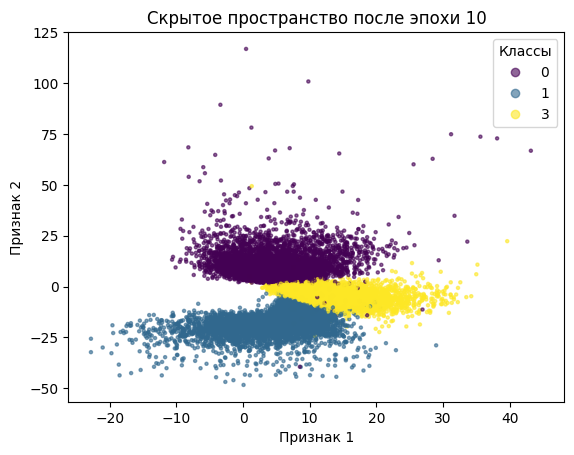

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0286
Итоговая ошибка MSE на 10-й эпохе: 0.02860
Условие выполнено: MSE < 0.034.


In [5]:
print('Старт обучения свёрточного автокодировщика...')

# Обучаем модель восстанавливать входное изображение по его сжатому представлению
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    callbacks=[ae_callback]
)

# Берём ошибку последней, десятой эпохи
final_mse = history.history['loss'][-1]

print(f'Итоговая ошибка MSE на 10-й эпохе: {final_mse:.5f}')

if final_mse < 0.034:
    print('Условие выполнено: MSE < 0.034.')
else:
    print('Условие не выполнено: MSE не ниже 0.034. Нужно перезапустить обучение или скорректировать модель.')
